In [1]:
# =============================================================
# TRABAJO DE FIN DE MÁSTER — MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA
# Universidad Internacional del Ecuador (UIDE)
#
# Título: Comparación de modelos de aprendizaje automático para
#         predecir el tiempo de llegada entre paradas en el
#         sistema BRT Ecovía de Quito utilizando registros
#         históricos de GPS
#
# Autores: Ortega Campus Jhon Henry
#          Ramos Mayorga Oscar Andrés
#          Torres Chango Christian Damian
#
# Notebook 03 — Comparación de modelos con MinMaxScaler
#
# Descripción:
# Este notebook implementa el pipeline completo de entrenamiento
# y evaluación de seis modelos de aprendizaje automático para
# predecir el tiempo de llegada entre paradas (eta_next_stop)
# en las 7 rutas del sistema BRT Ecovía de Quito.
#
# Modelos evaluados:
# → Promedio histórico      (baseline)
# → Regresión lineal        (baseline)
# → Hist Gradient Boosting  (ensemble)
# → XGBoost                 (ensemble)
# → LSTM                    (red neuronal recurrente)
# → GRU                     (red neuronal recurrente)
#
# Pipeline por ruta:
# 1. Exploración rápida de datos
# 2. Split temporal (70% train / 15% val / 15% test)
# 3. Normalización con MinMaxScaler (ajustado solo al train)
# 4. Construcción de ventanas temporales
# 5. Entrenamiento de los 6 modelos
# 6. Evaluación con MAE, RMSE y MAPE
# 7. Tabla comparativa por ruta
#
# Normalización: MinMaxScaler
# Arquitectura LSTM/GRU: 2 capas (64→32), Dropout=0.3, L2=0.001
# Optimizador: Adam lr=0.001, Batch=1024, EarlyStopping patience=5
#
# Ventana óptima por ruta:
# E1=7, E1M=5, E2_NS=5, E2_SN=10, E3_NS=10, E3_SN=7, E4=7
#
# Dataset: dataset_limpio.csv (24,308,817 registros × 15 columnas)
# Período: 15/09/2025 — 15/03/2026
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import gc
import time
import pickle

import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import regularizers

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print("=" * 60)
print("Notebook 03 — Comparación de modelos con MinMaxScaler")
print("Sistema BRT Ecovía de Quito")
print("=" * 60)
print(f"TensorFlow:  {tf.__version__}")
print(f"Normalización: MinMaxScaler")
print(f"Modelos:     Promedio histórico, Regresión lineal,")
print(f"             Hist Gradient Boosting, XGBoost, LSTM, GRU")
print(f"Rutas:       E1, E1M, E2_NS, E2_SN, E3_NS, E3_SN, E4")
print("=" * 60)

Notebook 03 — Comparación de modelos con MinMaxScaler
Sistema BRT Ecovía de Quito
TensorFlow:  2.21.0
Normalización: MinMaxScaler
Modelos:     Promedio histórico, Regresión lineal,
             Hist Gradient Boosting, XGBoost, LSTM, GRU
Rutas:       E1, E1M, E2_NS, E2_SN, E3_NS, E3_SN, E4


In [2]:
# =============================================================
# Carga del dataset limpio
# Se carga el dataset preprocesado generado en el
# notebook 02. Este dataset contiene 24,308,817 registros
# limpios y listos para el entrenamiento de los modelos.
#
# Dataset: dataset_limpio.csv
# Registros: 24,308,817 × 15 columnas
# Período: 15/09/2025 — 15/03/2026
# =============================================================

RUTA_DATASET = 'dataset_limpio.csv'

df = pd.read_csv(RUTA_DATASET)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

rutas_nombres = {
    55.0: 'E1', 58.0: 'E1M', 59.0: 'E2_NS',
    57.0: 'E2_SN', 56.0: 'E3_NS', 62.0: 'E3_SN', 60.0: 'E4'
}

print(f"Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nRegistros por ruta:")
print(f"{'Ruta':<8} {'Registros':>12} {'Porcentaje':>12}")
print("-" * 34)
for route_id, nombre in rutas_nombres.items():
    total = (df['route_id'] == route_id).sum()
    pct   = total / len(df) * 100
    print(f"{nombre:<8} {total:>12,} {pct:>11.1f}%")
print(f"\nPeríodo: {df['timestamp'].min().date()} → "
      f"{df['timestamp'].max().date()}")

Dataset cargado correctamente.
Dimensiones: 24,308,817 filas × 15 columnas

Registros por ruta:
Ruta        Registros   Porcentaje
----------------------------------
E1          8,568,477        35.2%
E1M         4,302,693        17.7%
E2_NS       4,055,368        16.7%
E2_SN       2,803,901        11.5%
E3_NS       2,167,708         8.9%
E3_SN       1,488,253         6.1%
E4            922,417         3.8%

Período: 2025-09-15 → 2026-03-14


In [3]:
# =============================================================
# Configuración del pipeline y definición de funciones
#
# Se definen las variables globales, hiperparámetros óptimos
# y las 9 funciones que conforman el pipeline automático
# de entrenamiento por ruta.
#
# Hiperparámetros óptimos determinados experimentalmente:
# → Batch size:          1024
# → Épocas máximas:      50 (con EarlyStopping patience=5)
# → Arquitectura LSTM/GRU: 2 capas (64→32 neuronas)
# → Dropout:             0.3
# → Regularización L2:   0.001
# → Optimizador:         Adam lr=0.001
# → ReduceLROnPlateau:   factor=0.5, patience=3
# =============================================================

RUTAS = {
    55.0: 'E1',  58.0: 'E1M', 59.0: 'E2_NS',
    57.0: 'E2_SN', 56.0: 'E3_NS', 62.0: 'E3_SN', 60.0: 'E4'
}

FEATURES = [
    'current_stop_id',    # parada actual
    'current_stop_order', # posición en la ruta
    'distance_to_next_stop', # variable más predictiva
    'speed',              # velocidad actual en km/h
    'acceleration',       # aceleración actual
    'time_since_last_stop', # segundos desde última parada
    'hour',               # hora del día
    'day_of_week',        # día de la semana (0=lunes)
    'is_weekend',         # 1 si es fin de semana
    'is_peak_hour',       # 1 si es hora pico
    'is_holiday',         # 1 si es feriado
]
TARGET     = 'eta_next_stop'
BATCH_SIZE = 1024
EPOCHS     = 50
SEED       = 42

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 1 — Exploración rápida por ruta
# Verifica que los datos de cada ruta estén dentro de los
# rangos esperados antes de iniciar el entrenamiento.
# ─────────────────────────────────────────────────────────────
def explorar_ruta(df_ruta, nombre_ruta):
    print(f"\n{'='*50}")
    print(f"EXPLORACIÓN — Ruta {nombre_ruta}")
    print(f"{'='*50}")
    print(f"Registros:      {len(df_ruta):,}")
    print(f"Viajes únicos:  {df_ruta['trip_id'].nunique():,}")
    print(f"Paradas únicas: {df_ruta['current_stop_id'].nunique()}")
    print(f"Valores nulos:  {df_ruta[FEATURES+[TARGET]].isnull().sum().sum()}")
    print(f"eta mínimo:     {df_ruta[TARGET].min():.3f} min")
    print(f"eta máximo:     {df_ruta[TARGET].max():.3f} min")
    print(f"eta promedio:   {df_ruta[TARGET].mean():.3f} min")
    print(f"speed máximo:   {df_ruta['speed'].max():.2f} km/h")
    print(f"Feriados:       {df_ruta['is_holiday'].sum():,} "
          f"({df_ruta['is_holiday'].sum()/len(df_ruta)*100:.2f}%)")

    ok = True
    if df_ruta[TARGET].min() < 0:
        print(" ERROR: eta negativo")
        ok = False
    if df_ruta['speed'].max() > 60:
        print(" ERROR: speed > 60 km/h")
        ok = False
    if df_ruta[FEATURES+[TARGET]].isnull().sum().sum() > 0:
        print(" ERROR: valores nulos")
        ok = False
    if ok:
        print(" Datos correctos")
    return ok

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 2 — Decidir ventana óptima
# Analiza la distribución de reportes por segmento y
# selecciona la ventana que maximiza los segmentos
# aprovechables sin sacrificar representatividad.
#
# Criterio de selección:
# → Ventana 7 si ≥ 40% de segmentos son aprovechables
# → Ventana 5 si ≥ 60% de segmentos son aprovechables
# → Ventana 10 en caso contrario
# ─────────────────────────────────────────────────────────────
def decidir_ventana(df_ruta, nombre_ruta):
    reportes = df_ruta.groupby(['trip_id', 'current_stop_id']).size()
    mediana  = reportes.median()

    cobertura = {}
    for n in [5, 7, 10]:
        pct = (reportes >= n).sum() / len(reportes) * 100
        cobertura[n] = pct

    print(f"\nReportes por segmento — mediana: {mediana:.1f}")
    for n, pct in cobertura.items():
        print(f"  Ventana {n}: {pct:.1f}% segmentos aprovechables")

    if cobertura[7] >= 40:
        ventana = 7
    elif cobertura[5] >= 60:
        ventana = 5
    else:
        ventana = 10

    print(f"→ Ventana óptima seleccionada: {ventana}")
    return ventana

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 3 — Split temporal
# Divide el dataset cronológicamente en tres conjuntos:
# → Train: 70% (datos más antiguos para aprendizaje)
# → Val:   15% (ajuste de hiperparámetros)
# → Test:  15% (evaluación final no vista por el modelo)
#
# Se usa split temporal en lugar de aleatorio para
# simular condiciones reales de predicción donde el
# modelo siempre predice datos futuros.
# ─────────────────────────────────────────────────────────────
def split_temporal(df_ruta):
    fecha_inicio = df_ruta['timestamp'].min()
    fecha_fin    = df_ruta['timestamp'].max()
    rango        = fecha_fin - fecha_inicio

    fecha_train  = fecha_inicio + rango * 0.70
    fecha_val    = fecha_inicio + rango * 0.85

    df_train = df_ruta[df_ruta['timestamp'] <= fecha_train].reset_index(drop=True)
    df_val   = df_ruta[(df_ruta['timestamp'] > fecha_train) &
                       (df_ruta['timestamp'] <= fecha_val)].reset_index(drop=True)
    df_test  = df_ruta[df_ruta['timestamp'] > fecha_val].reset_index(drop=True)

    print(f"\nSplit temporal:")
    print(f"  Train: {fecha_inicio.date()} → {fecha_train.date()} "
          f"({len(df_train):,} registros — 70%)")
    print(f"  Val:   {fecha_train.date()} → {fecha_val.date()} "
          f"({len(df_val):,} registros — 15%)")
    print(f"  Test:  {fecha_val.date()} → {fecha_fin.date()} "
          f"({len(df_test):,} registros — 15%)")

    return df_train, df_val, df_test

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 4 — Normalización con MinMaxScaler
# Escala las variables al rango [0, 1].
# El scaler se ajusta ÚNICAMENTE al conjunto de train
# para evitar data leakage hacia val y test.
# ─────────────────────────────────────────────────────────────
def normalizar(df_train, df_val, df_test):
    scaler  = MinMaxScaler()
    X_train = scaler.fit_transform(df_train[FEATURES])
    X_val   = scaler.transform(df_val[FEATURES])
    X_test  = scaler.transform(df_test[FEATURES])
    print(f"\nMinMaxScaler aplicado ")
    print(f"  Rango de salida: [0, 1]")
    print(f"  Ajustado solo al conjunto train")
    return scaler, X_train, X_val, X_test

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 5 — Construcción de ventanas temporales
# Construye secuencias de N reportes consecutivos
# agrupadas por trip_id + current_stop_id para que
# cada ventana pertenezca a un único segmento del viaje.
#
# Entrada: [reporte_1, ..., reporte_N] → predice eta_{N+1}
# ─────────────────────────────────────────────────────────────
def build_sequences(X_scaled, df_subset, seq_len):
    X_list, y_list = [], []
    grupos = df_subset.groupby(['trip_id', 'current_stop_id'])
    for _, grupo in grupos:
        idx = grupo.index.tolist()
        X_g = X_scaled[idx]
        y_g = df_subset.loc[idx, TARGET].values
        if len(X_g) > seq_len:
            for i in range(len(X_g) - seq_len):
                X_list.append(X_g[i:i+seq_len])
                y_list.append(y_g[i+seq_len])
    return np.array(X_list), np.array(y_list)

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 6 — Crear modelo LSTM
# Arquitectura de 2 capas con regularización L2 y Dropout
# para prevenir sobreajuste.
#
# Capa 1: LSTM(64) → Dropout(0.3)
# Capa 2: LSTM(32) → Dropout(0.3)
# Capa 3: Dense(16, relu)
# Salida: Dense(1) → eta_next_stop
# ─────────────────────────────────────────────────────────────
def crear_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True,
             kernel_regularizer=regularizers.l2(0.001),
             input_shape=input_shape),
        Dropout(0.3),
        LSTM(32, return_sequences=False,
             kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse', metrics=['mae'])
    return model

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 7 — Crear modelo GRU
# Misma arquitectura que LSTM pero con celdas GRU.
# GRU tiene menos parámetros que LSTM y es más eficiente
# computacionalmente manteniendo capacidad similar.
#
# Capa 1: GRU(64) → Dropout(0.3)
# Capa 2: GRU(32) → Dropout(0.3)
# Capa 3: Dense(16, relu)
# Salida: Dense(1) → eta_next_stop
# ─────────────────────────────────────────────────────────────
def crear_gru(input_shape):
    model = Sequential([
        GRU(64, return_sequences=True,
            kernel_regularizer=regularizers.l2(0.001),
            input_shape=input_shape),
        Dropout(0.3),
        GRU(32, return_sequences=False,
            kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse', metrics=['mae'])
    return model

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 8 — Callbacks de entrenamiento
# EarlyStopping: detiene el entrenamiento si val_loss
#   no mejora en 5 épocas y restaura los mejores pesos.
# ReduceLROnPlateau: reduce el learning rate a la mitad
#   si val_loss no mejora en 3 épocas consecutivas.
# ─────────────────────────────────────────────────────────────
def crear_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=0.00001, verbose=0)
    ]

# ─────────────────────────────────────────────────────────────
# FUNCIÓN 9 — Calcular métricas de evaluación
# MAE:  Error Absoluto Medio en minutos
# RMSE: Raíz del Error Cuadrático Medio en minutos
# MAPE: Error Porcentual Absoluto Medio
#       Se calcula solo sobre registros con eta ≥ 1 min
#       para evitar divisiones por valores muy pequeños.
# ─────────────────────────────────────────────────────────────
def calcular_metricas(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true >= 1.0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) /
                           y_true[mask])) * 100
    return mae, rmse, mape

print("=" * 60)
print(" Pipeline configurado correctamente")
print("=" * 60)
print(f"Variables predictoras: {len(FEATURES)}")
print(f"Variable objetivo:     {TARGET}")
print(f"Rutas a entrenar:      {list(RUTAS.values())}")
print(f"Batch size:            {BATCH_SIZE}")
print(f"Épocas máximas:        {EPOCHS}")
print(f"Semilla aleatoria:     {SEED}")
print(f"\nModelos a comparar:")
print(f"  1. Promedio histórico")
print(f"  2. Regresión lineal")
print(f"  3. Hist Gradient Boosting")
print(f"  4. XGBoost")
print(f"  5. LSTM")
print(f"  6. GRU")

 Pipeline configurado correctamente
Variables predictoras: 11
Variable objetivo:     eta_next_stop
Rutas a entrenar:      ['E1', 'E1M', 'E2_NS', 'E2_SN', 'E3_NS', 'E3_SN', 'E4']
Batch size:            1024
Épocas máximas:        50
Semilla aleatoria:     42

Modelos a comparar:
  1. Promedio histórico
  2. Regresión lineal
  3. Hist Gradient Boosting
  4. XGBoost
  5. LSTM
  6. GRU


In [5]:
# =============================================================
# Pipeline completo de entrenamiento y evaluación por ruta
#
# Para cada una de las 7 rutas del sistema Ecovía se ejecuta
# automáticamente el siguiente pipeline:
# 1. Exploración rápida de datos
# 2. Selección de ventana óptima
# 3. Split temporal (70/15/15)
# 4. Normalización con MinMaxScaler
# 5. Construcción de ventanas temporales
# 6. Entrenamiento de 6 modelos
# 7. Evaluación con MAE, RMSE y MAPE
# 8. Tabla comparativa por ruta
#
# Los modelos LSTM y GRU se guardan en formato .keras
# Los scalers se guardan en formato .pkl
# para su uso posterior en producción.
# =============================================================

resultados = {}

for route_id, nombre_ruta in RUTAS.items():

    print(f"\n{'#'*60}")
    print(f"# RUTA {nombre_ruta} (route_id={route_id})")
    print(f"{'#'*60}")

    # 1. Filtrar datos de la ruta
    df_ruta = df[df['route_id'] == route_id].copy().reset_index(drop=True)

    # 2. Exploración rápida
    ok = explorar_ruta(df_ruta, nombre_ruta)
    if not ok:
        print(f" Ruta {nombre_ruta} tiene problemas. Saltando.")
        continue

    # 3. Ventana óptima
    ventana = decidir_ventana(df_ruta, nombre_ruta)

    # 4. Split temporal
    df_train, df_val, df_test = split_temporal(df_ruta)

    # 5. Normalización
    scaler, X_train_sc, X_val_sc, X_test_sc = normalizar(
        df_train, df_val, df_test)

    # 6. Construcción de ventanas
    print(f"\nConstruyendo ventanas (seq_len={ventana})...")
    t0 = time.time()
    X_train, y_train = build_sequences(X_train_sc, df_train, ventana)
    X_val,   y_val   = build_sequences(X_val_sc,   df_val,   ventana)
    X_test,  y_test  = build_sequences(X_test_sc,  df_test,  ventana)
    print(f"  Train: {X_train.shape}  "
          f"({X_train.shape[0]:,} ventanas × {X_train.shape[1]} pasos × {X_train.shape[2]} features)")
    print(f"  Val:   {X_val.shape}")
    print(f"  Test:  {X_test.shape}")
    print(f"  Tiempo: {(time.time()-t0)/60:.1f} min")

    # Aplanar para modelos no secuenciales (XGBoost, HGB, Regresión)
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_val_flat   = X_val.reshape(X_val.shape[0], -1)
    X_test_flat  = X_test.reshape(X_test.shape[0], -1)

    resultados[nombre_ruta] = {'ventana': ventana}

    # 7. Promedio histórico (baseline)
    print(f"\n[1] Promedio histórico (baseline)...")
    y_pred = np.full(len(y_test), y_train.mean())
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados[nombre_ruta]['Promedio histórico'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  MAPE={mape:.2f}%")

    # 8. Regresión lineal (baseline)
    print(f"\n[2] Regresión lineal (baseline)...")
    lr = LinearRegression()
    lr.fit(X_train_flat, y_train)
    y_pred = lr.predict(X_test_flat)
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados[nombre_ruta]['Regresión lineal'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  MAPE={mape:.2f}%")

    # 9. Hist Gradient Boosting (ensemble)
    print(f"\n[3] Hist Gradient Boosting...")
    t0 = time.time()
    hgb = HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.1,
        max_depth=6, random_state=SEED)
    hgb.fit(X_train_flat, y_train)
    y_pred = hgb.predict(X_test_flat)
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados[nombre_ruta]['Gradient Boosting'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  "
          f"MAPE={mape:.2f}%  ({(time.time()-t0)/60:.1f}min)")

    # 10. XGBoost (ensemble)
    print(f"\n[4] XGBoost...")
    t0 = time.time()
    xgb = XGBRegressor(
        n_estimators=200, learning_rate=0.1,
        max_depth=6, random_state=SEED,
        tree_method='hist', verbosity=0)
    xgb.fit(X_train_flat, y_train,
            eval_set=[(X_val_flat, y_val)],
            verbose=False)
    y_pred = xgb.predict(X_test_flat)
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados[nombre_ruta]['XGBoost'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  "
          f"MAPE={mape:.2f}%  ({(time.time()-t0)/60:.1f}min)")

    # 11. LSTM (red neuronal recurrente)
    print(f"\n[5] LSTM...")
    t0 = time.time()
    model_lstm = crear_lstm((X_train.shape[1], X_train.shape[2]))
    model_lstm.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=crear_callbacks(), verbose=0)
    y_pred = model_lstm.predict(X_test, batch_size=1024, verbose=0).flatten()
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados[nombre_ruta]['LSTM'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  "
          f"MAPE={mape:.2f}%  ({(time.time()-t0)/60:.1f}min)")
    model_lstm.save(f'modelo_mm_lstm_{nombre_ruta}.keras')
    del model_lstm
    gc.collect()

    # 12. GRU (red neuronal recurrente)
    print(f"\n[6] GRU...")
    t0 = time.time()
    model_gru = crear_gru((X_train.shape[1], X_train.shape[2]))
    model_gru.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=crear_callbacks(), verbose=0)
    y_pred = model_gru.predict(X_test, batch_size=1024, verbose=0).flatten()
    mae, rmse, mape = calcular_metricas(y_test, y_pred)
    resultados[nombre_ruta]['GRU'] = (mae, rmse, mape)
    print(f"    MAE={mae*60:.1f}s  RMSE={rmse*60:.1f}s  "
          f"MAPE={mape:.2f}%  ({(time.time()-t0)/60:.1f}min)")
    model_gru.save(f'modelo_mm_gru_{nombre_ruta}.keras')
    with open(f'scaler_mm_{nombre_ruta}.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    del model_gru
    gc.collect()

    # Tabla de resultados por ruta
    print(f"\n{'='*57}")
    print(f"RESULTADOS RUTA {nombre_ruta} — MinMaxScaler (ventana={ventana})")
    print(f"{'='*57}")
    print(f"{'Modelo':<22} {'MAE(seg)':>9} {'RMSE(seg)':>10} {'MAPE(%)':>9}")
    print(f"{'-'*57}")
    for modelo, valor in resultados[nombre_ruta].items():
        if modelo == 'ventana':
            continue
        mae, rmse, mape = valor
        print(f"{modelo:<22} {mae*60:>9.1f} {rmse*60:>10.1f} {mape:>9.2f}")

    ganador = min(
        {k: v for k, v in resultados[nombre_ruta].items() if k != 'ventana'},
        key=lambda k: resultados[nombre_ruta][k][0])
    print(f"\n Ganador ruta {nombre_ruta}: {ganador} "
          f"— MAE={resultados[nombre_ruta][ganador][0]*60:.1f} seg")

    # Liberar memoria
    del df_ruta, df_train, df_val, df_test
    del X_train, y_train, X_val, y_val, X_test, y_test
    del X_train_flat, X_val_flat, X_test_flat
    gc.collect()

print(f"\n{'#'*60}")
print("PIPELINE MinMaxScaler COMPLETADO — TODAS LAS RUTAS")
print(f"{'#'*60}")


############################################################
# RUTA E1 (route_id=55.0)
############################################################

EXPLORACIÓN — Ruta E1
Registros:      8,568,477
Viajes únicos:  26,241
Paradas únicas: 45
Valores nulos:  0
eta mínimo:     0.017 min
eta máximo:     7.000 min
eta promedio:   1.433 min
speed máximo:   59.80 km/h
Feriados:       206,426 (2.41%)
 Datos correctos

Reportes por segmento — mediana: 7.0
  Ventana 5: 82.5% segmentos aprovechables
  Ventana 7: 51.3% segmentos aprovechables
  Ventana 10: 23.2% segmentos aprovechables
→ Ventana óptima seleccionada: 7

Split temporal:
  Train: 2025-09-15 → 2026-01-19 (5,949,186 registros — 70%)
  Val:   2026-01-19 → 2026-02-15 (1,330,499 registros — 15%)
  Test:  2026-02-15 → 2026-03-14 (1,288,792 registros — 15%)

MinMaxScaler aplicado 
  Rango de salida: [0, 1]
  Ajustado solo al conjunto train

Construyendo ventanas (seq_len=7)...
  Train: (1343628, 7, 11)  (1,343,628 ventanas × 7 pasos × 11 fea

In [6]:
# =============================================================
# Tabla comparativa final — MAE por ruta y modelo
# Se consolidan los resultados de todas las rutas en una
# tabla comparativa que permite identificar el mejor modelo
# para el sistema BRT Ecovía con normalización MinMaxScaler.
# =============================================================

modelos_orden = [
    'Promedio histórico',
    'Regresión lineal',
    'Gradient Boosting',
    'XGBoost',
    'LSTM',
    'GRU'
]
rutas_orden = ['E1', 'E1M', 'E2_NS', 'E2_SN', 'E3_NS', 'E3_SN', 'E4']

# =============================================================
# Tabla MAE por ruta (en segundos)
# =============================================================
print("=" * 97)
print("COMPARACIÓN FINAL MAE (segundos) — MinMaxScaler — Sistema BRT Ecovía")
print("=" * 97)
print(f"{'Modelo':<22} {'E1':>8} {'E1M':>8} {'E2_NS':>8} {'E2_SN':>8} "
      f"{'E3_NS':>8} {'E3_SN':>8} {'E4':>8} {'Prom':>8}")
print(f"{'':22} {'(v=7)':>8} {'(v=5)':>8} {'(v=5)':>8} {'(v=10)':>8} "
      f"{'(v=10)':>8} {'(v=7)':>8} {'(v=7)':>8} {'':>8}")
print("-" * 97)

for modelo in modelos_orden:
    maes = []
    fila = f"{modelo:<22}"
    for ruta in rutas_orden:
        mae = resultados[ruta][modelo][0] * 60
        maes.append(mae)
        fila += f" {mae:>8.1f}"
    fila += f" {np.mean(maes):>8.1f}"
    print(fila)

print("=" * 97)

# =============================================================
# Tabla RMSE por ruta (en segundos)
# =============================================================
print("\n" + "=" * 97)
print("COMPARACIÓN FINAL RMSE (segundos) — MinMaxScaler — Sistema BRT Ecovía")
print("=" * 97)
print(f"{'Modelo':<22} {'E1':>8} {'E1M':>8} {'E2_NS':>8} {'E2_SN':>8} "
      f"{'E3_NS':>8} {'E3_SN':>8} {'E4':>8} {'Prom':>8}")
print("-" * 97)

for modelo in modelos_orden:
    rmses = []
    fila  = f"{modelo:<22}"
    for ruta in rutas_orden:
        rmse = resultados[ruta][modelo][1] * 60
        rmses.append(rmse)
        fila += f" {rmse:>8.1f}"
    fila += f" {np.mean(rmses):>8.1f}"
    print(fila)

print("=" * 97)

# =============================================================
# Tabla MAPE por ruta (en porcentaje)
# =============================================================
print("\n" + "=" * 97)
print("COMPARACIÓN FINAL MAPE (%) — MinMaxScaler — Sistema BRT Ecovía")
print("=" * 97)
print(f"{'Modelo':<22} {'E1':>8} {'E1M':>8} {'E2_NS':>8} {'E2_SN':>8} "
      f"{'E3_NS':>8} {'E3_SN':>8} {'E4':>8} {'Prom':>8}")
print("-" * 97)

for modelo in modelos_orden:
    mapes = []
    fila  = f"{modelo:<22}"
    for ruta in rutas_orden:
        mape = resultados[ruta][modelo][2]
        mapes.append(mape)
        fila += f" {mape:>8.2f}"
    fila += f" {np.mean(mapes):>8.2f}"
    print(fila)

print("=" * 97)

# =============================================================
# Ranking final por MAE promedio
# =============================================================
print("\n" + "=" * 55)
print("RANKING FINAL — MAE PROMEDIO — MinMaxScaler")
print("=" * 55)
print(f"{'Pos':<5} {'Modelo':<22} {'MAE prom':>10} {'RMSE prom':>10} {'MAPE prom':>10}")
print("-" * 55)

ranking = {}
for modelo in modelos_orden:
    maes  = [resultados[r][modelo][0]*60 for r in rutas_orden]
    rmses = [resultados[r][modelo][1]*60 for r in rutas_orden]
    mapes = [resultados[r][modelo][2]    for r in rutas_orden]
    ranking[modelo] = (np.mean(maes), np.mean(rmses), np.mean(mapes))

for pos, (modelo, (mae, rmse, mape)) in enumerate(
    sorted(ranking.items(), key=lambda x: x[1][0]), 1):
    print(f"{pos:<5} {modelo:<22} {mae:>10.1f} {rmse:>10.1f} {mape:>10.2f}")

print("=" * 55)
ganador = min(ranking, key=lambda k: ranking[k][0])
print(f"\n Mejor modelo: {ganador}")
print(f"   MAE promedio:  {ranking[ganador][0]:.1f} segundos")
print(f"   RMSE promedio: {ranking[ganador][1]:.1f} segundos")
print(f"   MAPE promedio: {ranking[ganador][2]:.2f}%")

COMPARACIÓN FINAL MAE (segundos) — MinMaxScaler — Sistema BRT Ecovía
Modelo                       E1      E1M    E2_NS    E2_SN    E3_NS    E3_SN       E4     Prom
                          (v=7)    (v=5)    (v=5)   (v=10)   (v=10)    (v=7)    (v=7)         
-------------------------------------------------------------------------------------------------
Promedio histórico         52.1     59.2     59.6     22.4     42.6     46.1     55.9     48.3
Regresión lineal           30.7     35.4     32.1     15.1     27.3     27.0     29.8     28.2
Gradient Boosting          19.6     20.9     22.1     10.4     19.9     18.3     22.9     19.2
XGBoost                    19.3     20.7     21.9     10.4     19.8     18.1     22.7     19.0
LSTM                       21.6     23.6     23.1     13.6     24.0     20.9     27.1     22.0
GRU                        20.8     23.0     23.1     13.4     22.9     21.7     26.7     21.7

COMPARACIÓN FINAL RMSE (segundos) — MinMaxScaler — Sistema BRT Ecovía
Mo

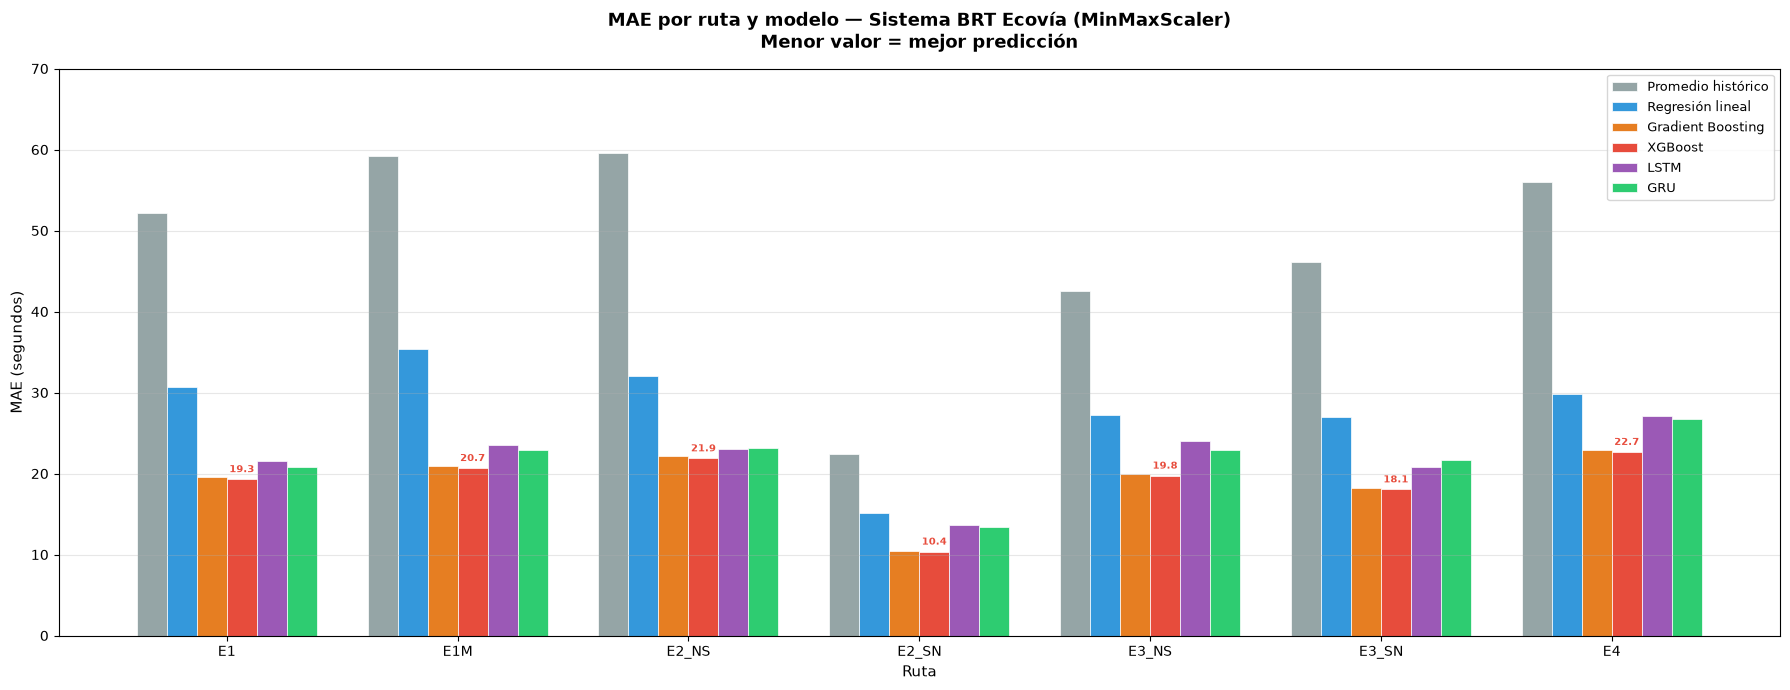

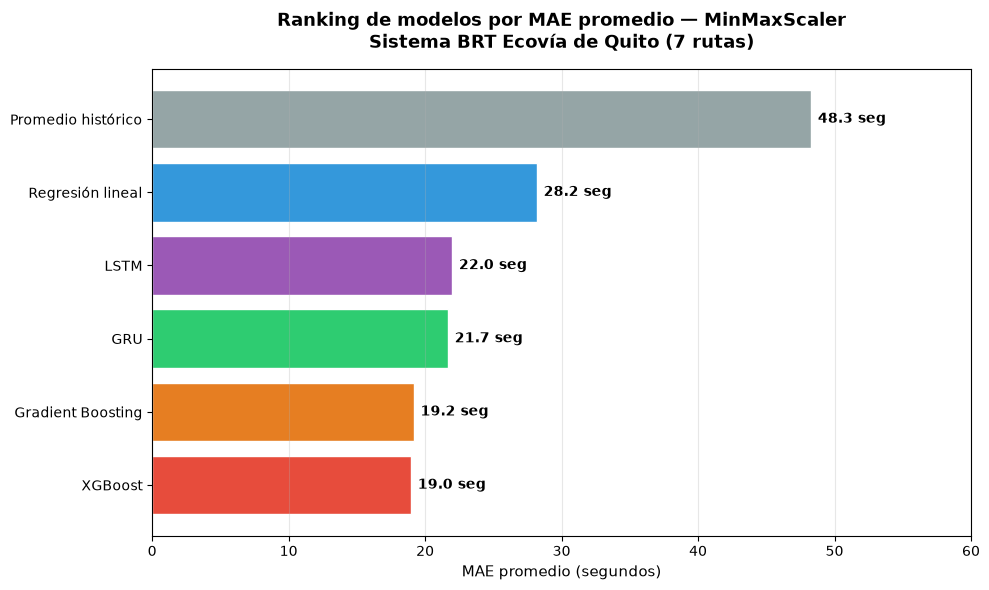

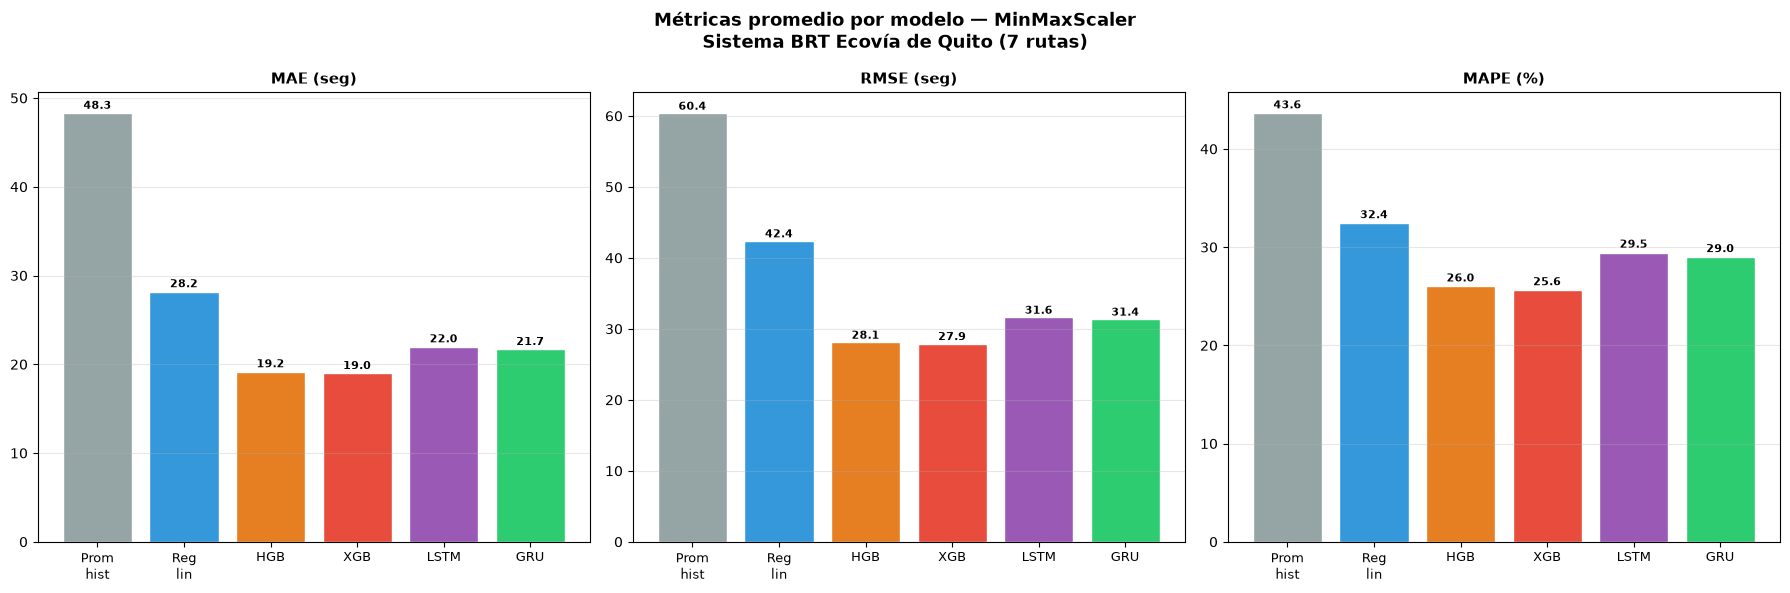

 Gráficas guardadas:
   → comparacion_mae_por_ruta.png
   → ranking_mae_promedio_mm.png
   → metricas_promedio_mm.png


In [9]:
# =============================================================
# Visualización comparativa de resultados
# Gráficas de barras agrupadas por ruta para cada métrica
# que permiten identificar visualmente el mejor modelo
# en el sistema BRT Ecovía con normalización MinMaxScaler.
# =============================================================

import matplotlib.pyplot as plt
import numpy as np

colores_modelos = {
    'Promedio histórico': '#95a5a6',
    'Regresión lineal':   '#3498db',
    'Gradient Boosting':  '#e67e22',
    'XGBoost':            '#e74c3c',
    'LSTM':               '#9b59b6',
    'GRU':                '#2ecc71'
}

rutas_orden   = ['E1', 'E1M', 'E2_NS', 'E2_SN', 'E3_NS', 'E3_SN', 'E4']
modelos_orden = ['Promedio histórico', 'Regresión lineal',
                 'Gradient Boosting', 'XGBoost', 'LSTM', 'GRU']

x        = np.arange(len(rutas_orden))
n_models = len(modelos_orden)
width    = 0.13

# =============================================================
# Gráfica 1 — MAE por ruta y modelo
# =============================================================
fig, ax = plt.subplots(figsize=(18, 7))

for i, modelo in enumerate(modelos_orden):
    maes = [resultados[r][modelo][0]*60 for r in rutas_orden]
    bars = ax.bar(x + i*width, maes, width,
                  label=modelo,
                  color=colores_modelos[modelo],
                  edgecolor='white', linewidth=0.5)

ax.set_title('MAE por ruta y modelo — Sistema BRT Ecovía (MinMaxScaler)\n'
             'Menor valor = mejor predicción',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Ruta', fontsize=11)
ax.set_ylabel('MAE (segundos)', fontsize=11)
ax.set_xticks(x + width * (n_models-1)/2)
ax.set_xticklabels(rutas_orden, fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 70)

# Anotar valores de XGBoost
for i_r, ruta in enumerate(rutas_orden):
    mae_xgb = resultados[ruta]['XGBoost'][0]*60
    ax.annotate(f'{mae_xgb:.1f}',
                xy=(x[i_r] + 3*width, mae_xgb),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=7.5,
                color=colores_modelos['XGBoost'],
                fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_mae_por_ruta.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Gráfica 2 — MAE promedio por modelo (ranking visual)
# =============================================================
fig, ax = plt.subplots(figsize=(10, 6))

maes_prom = {m: np.mean([resultados[r][m][0]*60 for r in rutas_orden])
             for m in modelos_orden}
modelos_sorted = sorted(maes_prom, key=maes_prom.get)
valores_sorted = [maes_prom[m] for m in modelos_sorted]
colores_sorted = [colores_modelos[m] for m in modelos_sorted]

bars = ax.barh(modelos_sorted, valores_sorted,
               color=colores_sorted, edgecolor='white')

ax.set_title('Ranking de modelos por MAE promedio — MinMaxScaler\n'
             'Sistema BRT Ecovía de Quito (7 rutas)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('MAE promedio (segundos)', fontsize=11)
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, valores_sorted):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} seg',
            va='center', ha='left', fontsize=10,
            fontweight='bold')

ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig('ranking_mae_promedio_mm.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Gráfica 3 — Comparación MAE, RMSE, MAPE promedio
# =============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Métricas promedio por modelo — MinMaxScaler\n'
             'Sistema BRT Ecovía de Quito (7 rutas)',
             fontsize=13, fontweight='bold')

metricas = ['MAE (seg)', 'RMSE (seg)', 'MAPE (%)']
for idx, (metrica, ax) in enumerate(zip(metricas, axes)):
    valores = []
    for modelo in modelos_orden:
        if idx == 0:
            v = np.mean([resultados[r][modelo][0]*60 for r in rutas_orden])
        elif idx == 1:
            v = np.mean([resultados[r][modelo][1]*60 for r in rutas_orden])
        else:
            v = np.mean([resultados[r][modelo][2] for r in rutas_orden])
        valores.append(v)

    bars = ax.bar(range(len(modelos_orden)), valores,
                  color=[colores_modelos[m] for m in modelos_orden],
                  edgecolor='white')
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(modelos_orden)))
    ax.set_xticklabels(['Prom\nhist', 'Reg\nlin', 'HGB',
                        'XGB', 'LSTM', 'GRU'], fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('metricas_promedio_mm.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Gráficas guardadas:")
print("   → comparacion_mae_por_ruta.png")
print("   → ranking_mae_promedio_mm.png")
print("   → metricas_promedio_mm.png")

## Conclusiones - Comparación de modelos con MinMaxScaler

### Hallazgo principal
XGBoost obtuvo el mejor rendimiento en **todas las rutas** y en **todas las métricas** con un MAE promedio de **19.0 segundos**, seguido de HistGradientBoosting con 19.2 segundos.

### Rendimiento por tipo de modelo

| Tipo | Modelos | MAE prom | Observación |
|---|---|---|---|
| Ensemble | XGBoost, HGB | 19.0 - 19.2 seg | Mejor rendimiento |
| RNN | GRU, LSTM | 21.7 - 22.0 seg | Segundo lugar |
| Baseline | Reg. lineal | 28.2 seg | Referencia |
| Baseline | Prom. histórico | 48.3 seg | Peor resultado |

### Análisis por ruta

- **Mejor ruta:** E2_SN con MAE=10.4 seg (XGBoost) — segmentos cortos y consistentes
- **Peor ruta:** E4 con MAE=22.7 seg (XGBoost) — mayor variabilidad operativa
- **XGBoost supera a GRU** en todas las rutas con una diferencia promedio de 2.7 segundos

### ¿Por qué XGBoost supera a LSTM y GRU?

Los segmentos del sistema Ecovía tienen una duración promedio de **1.3 minutos**. En segmentos tan cortos la variable más determinante es `distance_to_next_stop` (correlación hasta 0.84), no la dependencia temporal de largo plazo que LSTM y GRU están diseñados para capturar. XGBoost identifica estas relaciones no lineales de forma más eficiente con menor costo computacional.

### Impacto de la normalización MinMaxScaler

MinMaxScaler escala las variables al rango [0, 1]. Es adecuado para XGBoost y HGB que no dependen de la escala, pero puede no ser óptimo para LSTM y GRU que usan funciones de activación tanh centradas en 0. Este aspecto se analiza en el notebook 04 con StandardScaler.